In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

import kind
import ex_duffing
import reinforcement_learning as rl
import util_data

In [2]:
data_path = '../../data/dreamer/duffing_all_0.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
replay = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy()), 0)

print(replay.shape)

torch.Size([1, 626, 4])


In [3]:
replay_factory = ex_duffing.replay_factory()

In [4]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 4, "cos": 4}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.back_nsample, args.fore_nsample), setpoint, load_normalized=False)

model = kind.model_adapter(model, dataset.normalizer)

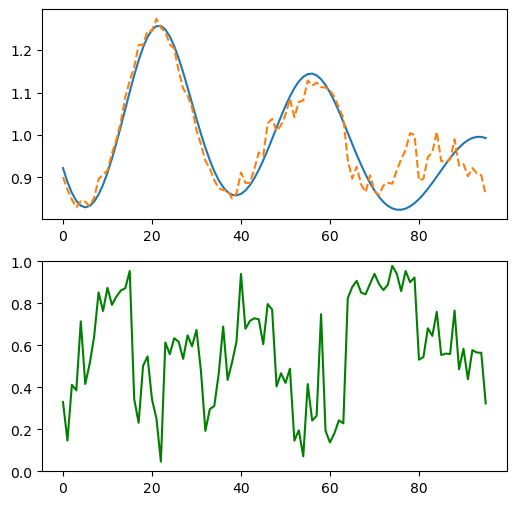

In [5]:
offset = 90

with torch.no_grad():
    true = replay[:, offset:offset + args.back_nsample + args.fore_nsample, :2]
    back = replay[:, offset:offset + args.back_nsample]

    model_o = model(back)

    plt.figure(figsize=(6,6))

    plt.subplot(2,1,1)
    plt.plot(true[0, :, 0])
    plt.plot(model_o.blend[0, :, 0], linestyle='dashed')

    plt.subplot(2,1,2)
    plt.plot(model_o.alpha[0, :, 0], color='green')
    plt.ylim((0.0, 1.0))

    plt.show()

#print(tata.shape)

In [6]:
state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 10.0 * np.eye(action_ndim)

dt = 1e-2
setpoint = [1.0, 0.0]

base_policy, _ = ex_duffing.make_base_policy(
    -1.0, 0.5,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)

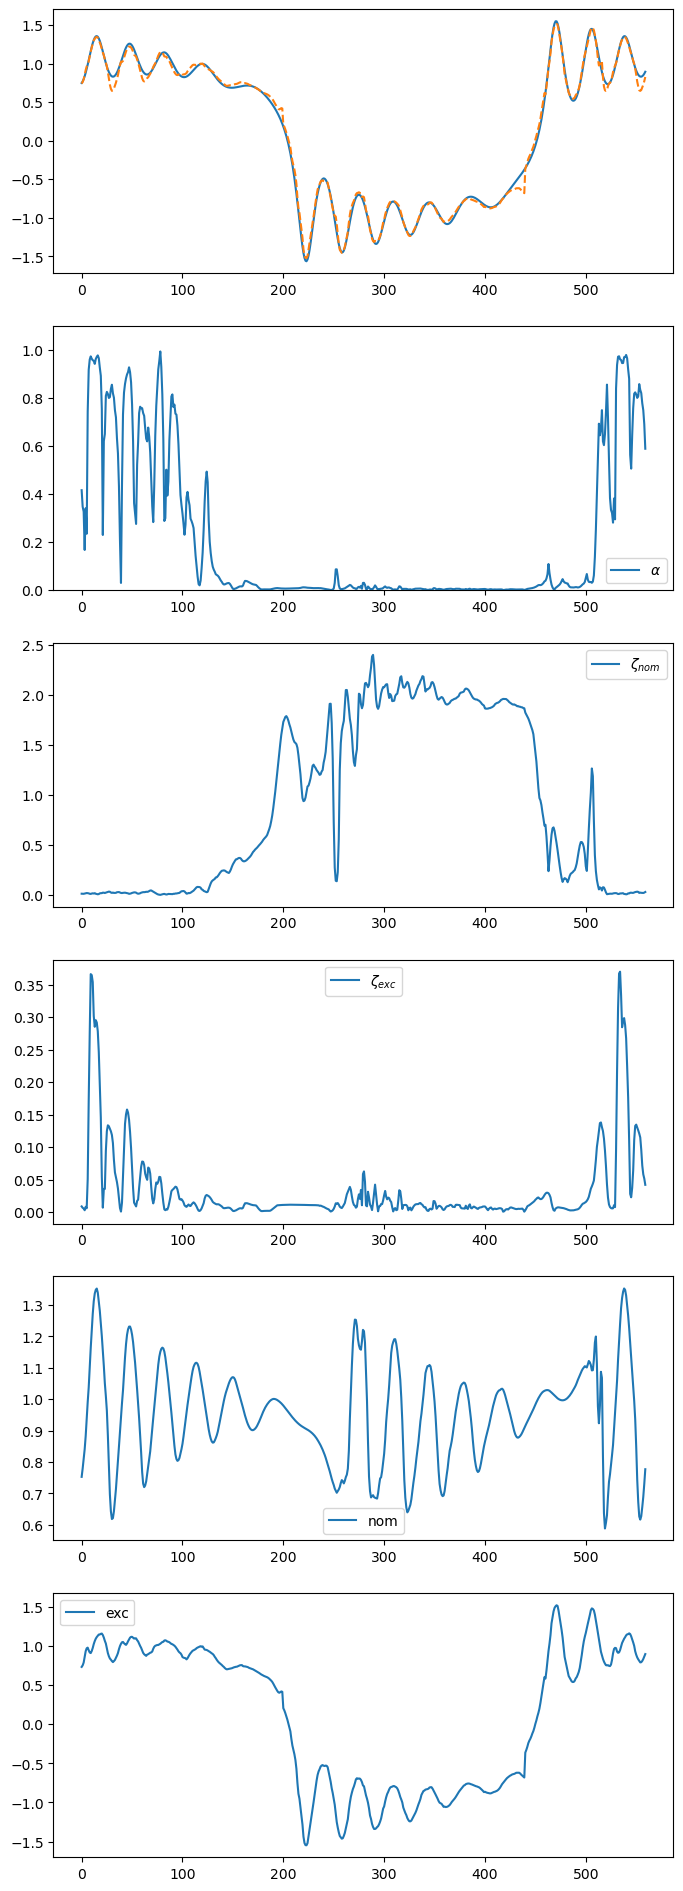

In [7]:
offset = 0
h = 560
rollout_nsample = 20

next_ss = []
alphas = []
means_nom = []
means_exc = []
zetas_nom = []
zetas_exc = []

back = replay[:, offset:offset + args.back_nsample].clone()
true = replay[:, offset + args.back_nsample:offset + args.back_nsample + h]

with torch.no_grad():

    for k in range(h):
        if k % rollout_nsample == 0:
            t2 = offset + args.back_nsample + k
            t1 = t2 - args.back_nsample
            back = replay[:, t1:t2].clone()

        s = replay_factory.extract_current_s(back)
        a = base_policy(s)

        replay_factory.update_current_a(back, a)
        model_o = model(back)

        fore = model_o.blend[:, args.back_nsample:]
        next_s = fore[:, :1]
        back = replay_factory.update_state(back, next_s)

        alpha = model_o.alpha[:, args.back_nsample:]
        alpha = alpha[:, :1]

        zeta_nom = model_o.zeta_nom[:, args.back_nsample:]
        zeta_nom = zeta_nom[:, :1]

        zeta_exc = model_o.zeta_exc[:, args.back_nsample:]
        zeta_exc = zeta_exc[:, :1]

        mean_nom = model_o.mean_nom[:, args.back_nsample:]
        mean_nom = mean_nom[:, :1]

        mean_exc = model_o.mean_exc[:, args.back_nsample:]
        mean_exc = mean_exc[:, :1]

        next_ss.append(next_s)
        alphas.append(alpha)
        zetas_nom.append(zeta_nom)
        zetas_exc.append(zeta_exc)
        means_nom.append(mean_nom)
        means_exc.append(mean_exc)

    next_ss = torch.cat(next_ss, dim=1)
    alphas = torch.cat(alphas, dim=1)
    zetas_nom = torch.cat(zetas_nom, dim=1)
    zetas_exc = torch.cat(zetas_exc, dim=1)
    means_nom = torch.cat(means_nom, dim=1)
    means_exc = torch.cat(means_exc, dim=1)

    plt.figure(figsize=(8,24))

    plt.subplot(6,1,1)
    plt.plot(true[0, :, 0])
    plt.plot(next_ss[0, :, 0], linestyle='dashed')

    plt.subplot(6,1,2)
    plt.plot(alphas[0, :, 0], label='$\\alpha$')
    plt.ylim((0.0, 1.1))
    plt.legend()

    plt.subplot(6,1,3)
    plt.plot(zetas_nom[0, :, 0], label='$\\zeta_{nom}$')
    plt.legend()

    plt.subplot(6,1,4)
    plt.plot(zetas_exc[0, :, 0], label='$\\zeta_{exc}$')
    plt.legend()

    plt.subplot(6,1,5)
    plt.plot(means_nom[0, :, 0], label='nom')
    plt.legend()

    plt.subplot(6,1,6)
    plt.plot(means_exc[0, :, 0], label='exc')
    plt.legend()

    plt.show()


In [8]:
datasaved = False

if datasaved:
    step = torch.arange(true.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        step,
        true[..., :1], next_ss[..., :1], alphas[..., :1], zetas_nom[..., :1]], axis=2)
    util_data.write_datafile(f'../../results/dreamer/duffing_kind_replay', savedata, delim=' ')